# Measurement noise and `diag_error_structure`

MOOGP separates the latent signal from observation noise. There is one variance
term $\sigma^2_\varepsilon$ per output. You can:

  * **learn** it from the data (the default when `sigma_eps2` is not given),
  * **fix** it to known values via `sigma_eps2=[...]`, or
  * **group** outputs that share a single variance via `diag_error_structure`.

```python
MOOGP(terms, q)                                # learn the noise (default)
MOOGP(terms, q, sigma_eps2=[10.0, 1.0, 0.05])  # fixed, known noise
MOOGP(terms, q, diag_error_structure=[2, 4])   # groups share: ([1,2], [3,4,5,6])
```

This notebook covers all three and shows how the noise affects predictions.

In [4]:
# !pip install moogp
# !pip install matplotlib

import numpy as np
import matplotlib.pyplot as plt

from moogp.model import MOOGP
from moogp.datasets import generate_forrester_data

## 1. Learned vs fixed noise

We generate three-output data from the [Forrester funcion](https://www.sfu.ca/~ssurjano/forretal08.html) with known per-output noise variances, then fit
two models: one that learns the noise (default) and one given the true values.
The learned variances should land near the truth.

In [5]:
sigma_eps2_true = np.array([10.0, 1.0, 0.05])
data = generate_forrester_data(n=80, seed=0, with_error=True,
                               error_per_output=sigma_eps2_true)

m_learn = MOOGP(terms=[None, 1], q=3, learn_sigma_eps=True)       # default
m_learn.fit(data, optimizer_opts={"maxiter": 400})

m_fixed = MOOGP(terms=[None, 1], q=3, sigma_eps2=sigma_eps2_true)  # fixed/known
m_fixed.fit(data, optimizer_opts={"maxiter": 400})

print("true   sigma_eps2:", sigma_eps2_true)
print("learned sigma_eps2:", np.round(m_learn.cache["sigma_eps2_raw"], 3))

true   sigma_eps2: [10.    1.    0.05]
learned sigma_eps2: [10.299  0.858  0.059]


## 2. How the noise level shapes predictions

With near zero noise the GP nearly interpolates the training points and the
predictive band collapses at the data. With a large noise variance the model
treats the observations as noisy, smooths through them, and reports a wider band.
We illustrate both extremes on across all three outputs.

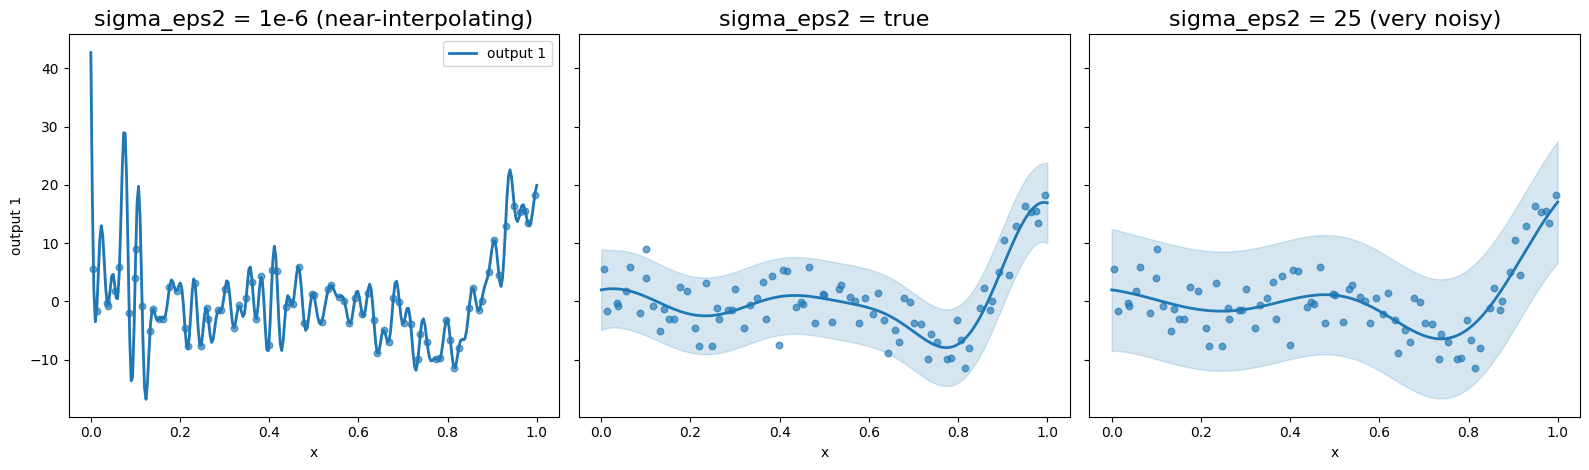

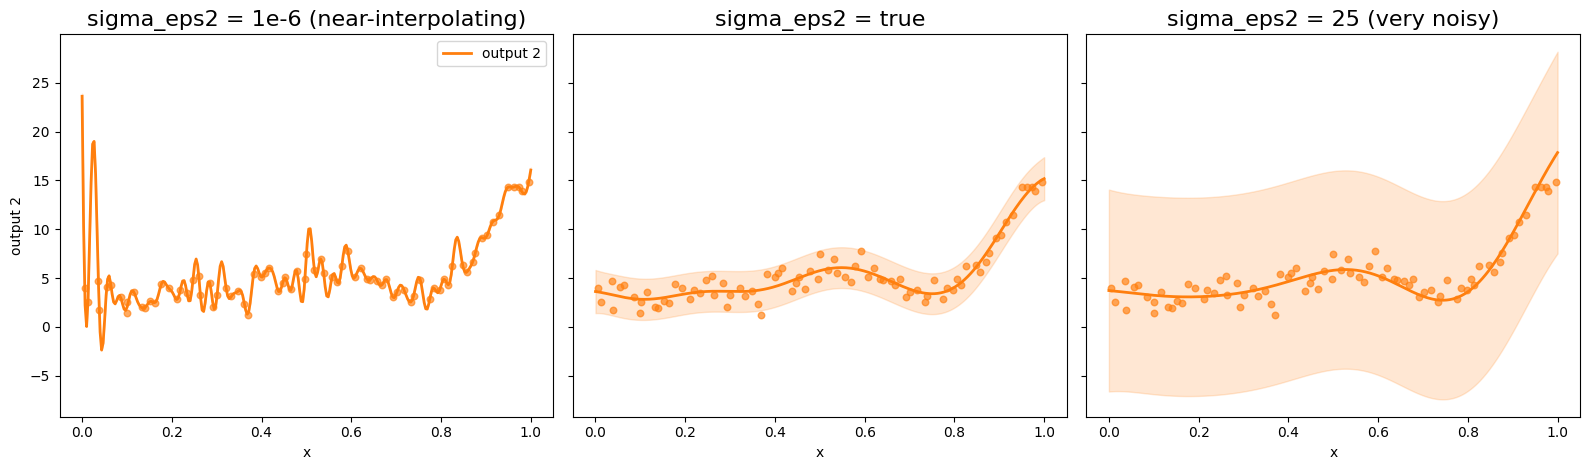

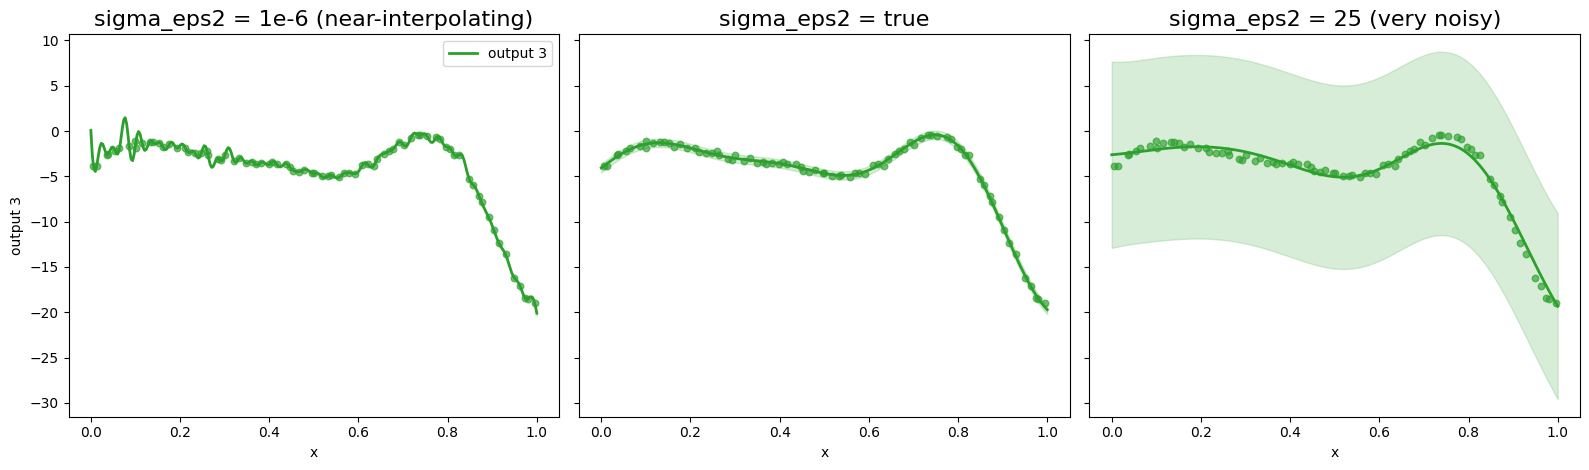

In [7]:
X, Y = data["X"], data["y"]
xg = np.linspace(0, 1, 300).reshape(-1, 1)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fits = {
    "sigma_eps2 = 1e-6 (near-interpolating)": np.full(3, 1e-6),
    "sigma_eps2 = true": sigma_eps2_true,
    "sigma_eps2 = 25 (very noisy)": np.full(3, 25.0),
}

fit_results = []
for label, s2 in fits.items():
    m = MOOGP(terms=[None, 1], q=3, sigma_eps2=s2)
    m.fit(data, optimizer_opts={"maxiter": 300})
    mean, std = m.predict(xg, return_std=True)
    fit_results.append((label, mean, std))

for out in range(Y.shape[1]):
    fig, axes = plt.subplots(1, len(fit_results), figsize=(16, 4.8), sharey=True)
    color = colors[out]
    for ax, (label, mean, std) in zip(axes, fit_results):
        ax.fill_between(xg[:, 0], mean[:, out] - 2 * std[:, out],
                        mean[:, out] + 2 * std[:, out], color=color, alpha=0.18)
        ax.plot(xg[:, 0], mean[:, out], color=color, lw=2, label=f"output {out + 1}")
        ax.scatter(X[:, 0], Y[:, out], s=22, color=color, alpha=0.65)
        ax.set_title(label, fontsize=16)
        ax.set_xlabel("x")
    axes[0].set_ylabel(f"output {out + 1}")
    axes[0].legend(fontsize=10)
    fig.tight_layout()

`predict_observation` controls whether the returned standard deviation includes
the measurement noise. Use the default (`True`) when predicting a future *noisy
observation*, and `False` for the uncertainty of the underlying *latent
function*.

In [4]:
_, std_obs = m_learn.predict(X, return_std=True, predict_observation=True)
_, std_fun = m_learn.predict(X, return_std=True, predict_observation=False)
print("median std incl. noise (observation):", np.round(np.median(std_obs, 0), 3))
print("median std excl. noise (latent f):   ", np.round(np.median(std_fun, 0), 3))

median std incl. noise (observation): [3.348 0.968 0.255]
median std excl. noise (latent f):    [0.955 0.281 0.074]


## 3. Grouping outputs with `diag_error_structure`

When several outputs share a noise level, you can tie their variances together by
passing the list of **group sizes** (which must sum to `p`). This fits fewer
parameters and stabilizes the estimate. Following the README example: six outputs
where the first two are measured precisely and the remaining four are noisy.

In [8]:
n = 100
x = np.linspace(0.0, 1.0, n).reshape(-1, 1)
rng = np.random.default_rng(0)
Y6 = np.column_stack([
    np.sin(2 * x), np.cos(2 * x),                                   # low-noise
    np.sin(x / 2), np.cos(x / 2), np.sin(x / 3), np.cos(x / 3),     # high-noise
])
Y6[:, :2] += rng.normal(0, 1e-3, size=(n, 2))   # precise outputs
Y6[:, 2:] += rng.normal(0, 1e-1, size=(n, 4))   # noisy outputs

# Group the first 2 and the remaining 4 outputs -> two noise variances.
model = MOOGP(terms=[None, 1], q=4, diag_error_structure=[2, 4])
model.fit({"X": x, "Y": Y6}, optimizer_opts={"maxiter": 400})

print("diag_error_structure:", model.diag_error_structure)
# On the model's internal (standardized) scale, the two groups are tied:
print("working-scale sigma_eps2:", np.round(model.cache["sigma_eps2"], 4))

diag_error_structure: (2, 4)
working-scale sigma_eps2: [0.0778 0.0778 0.5    0.5    0.5    0.5   ]


The six per-output variances collapse to just two distinct values on the
working scale — one shared by outputs 1–2 and another shared by outputs 3–6 —
exactly the `[2, 4]` grouping. (On the original scale, `sigma_eps2_raw` differs
per output because each output is rescaled by its own standard deviation during
standardization.)

### Takeaways

  * Default: the noise is learned per output.
  * Pass `sigma_eps2=[...]` to fix known variances; lower noise → tighter fit to
    the data, higher noise → more smoothing and wider bands.
  * `predict_observation` toggles whether the predictive std includes the noise.
  * `diag_error_structure=[...]` ties groups of outputs to a shared variance.